#### Visualizaciones
##### Vamos a visualizar al menos un gráfico por cada metodo creado de la clase Visulizador

##### Importamos los mudulos necesarios

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from gestor import gestion
from visualizacion.visualizaciones import Visualizador
from eda.analisis_eda import ProcesadorEDA

##### Cargamos el dataframe a utilizar

In [18]:
df_final = pd.read_csv(r"C:\world_cup_insights\data\processed\partidos-mundial-procesado.csv", header=0, sep=',')

##### Empezamos creando el objeto a partir de la clase Visualizador

In [19]:
graficos = Visualizador()

#### Histograma
##### Veremos a traves de este histograma como se distribuyen los resultados de un Mundial, son comunes las goleadas, o la mayoria de resultados son cerrados.

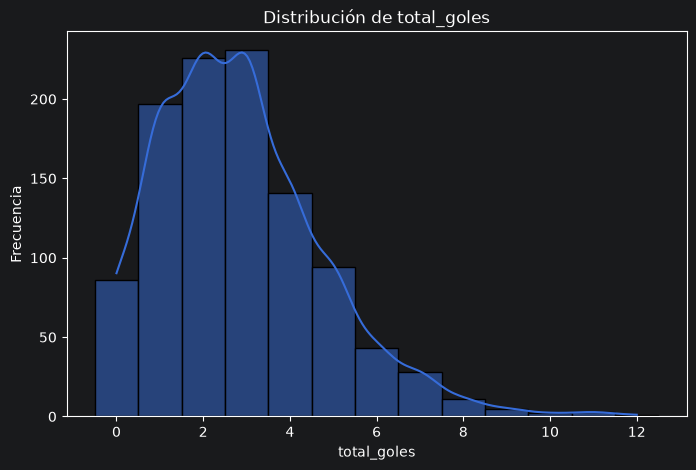

In [20]:
graficos.histograma(df_final, 'total_goles')

##### Podemos observar la frecuencia de total de goles en la totalidad de partidos de todos los mundiales celebrados, donde podemos observar que la totalidad suele ser baja, con el grueso de los datos entre 1 a 3 goles es decir los resultados suelen ser cerrados, esto a nivel estadistico se ve claramente con un gráfico que forma claramente una campana de gauss pero con un sesgo positivo.

#### Gráfico de barras
##### Veremos mediante un gráfico de barras cuál fue el mundial más ofensivo, y en que edicion se metieron más goles en promedio.

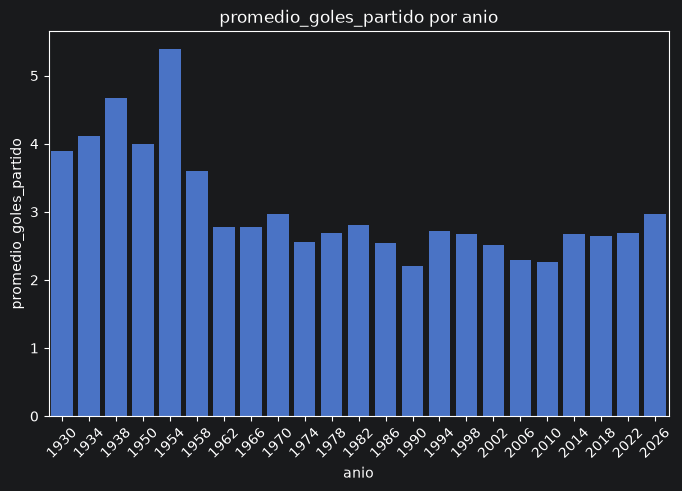

In [21]:
agrupacion_edicion = ProcesadorEDA(df_final)
graficos.grafico_barras(agrupacion_edicion.agrupacion_por_edicion(), 'anio', 'promedio_goles_partido')

##### Podemos observar que el pico de promedio de goles se dio en la edicion de 1954 donde aunque había menos equipos, el formato era distinto, pero existia menos tactica defensiva y estaba menos profesionalizado

#### Gráfico de líneas
##### Aquí responderemos a la pregunta: ¿Ha evolucionado el futbol como espectaculo atraves de los anios?

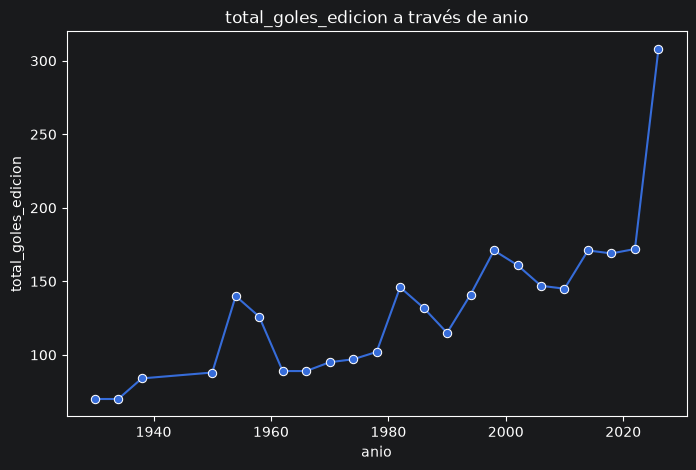

In [22]:
graficos.grafico_lineas(agrupacion_edicion.agrupacion_por_edicion(), 'anio', 'total_goles_edicion')

##### Aca podemos observar que conforme ha aumentado el número de equipos en las ediciones y el crecimiento del futbol a nivel mundial, se meten más goles en total, por tanto, el espectaculo es más vistoso

#### Mapa de calor de la matriz de correlacion
##### Veremos de las variables numericas disponibles como se relacionan entre sí y con que fuerza y magnitud

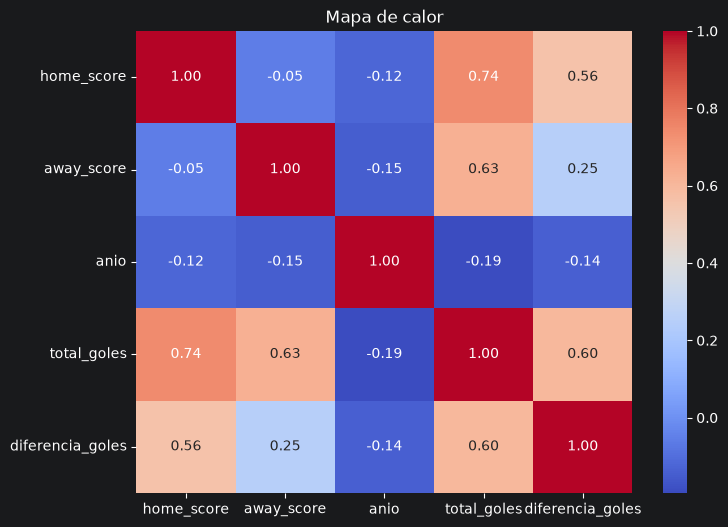

In [23]:

graficos.heatmap(agrupacion_edicion.matriz_correlacion())

##### Entre las relaciones más llamativas podemos ver que los goles metidos en casa tiene una relacion alta y positiva que entre más goles por el equipo "local" mayor se vuelve la difrencia, mientras que el total y los anotados por el equipo "visitante" también es positiva pero mas moderada, mientras que la diferencia de goles matiene una relacion positiva, moderada con los goles del equipo de casa y el total de goles pero no con el equipo visitante, el resto de relaciones es baja positiva y negativas,

#### Gráfico de dispersion
##### Verificaremos mas een detalle esa relacion fuerte entre los goles en casa y el total de goles

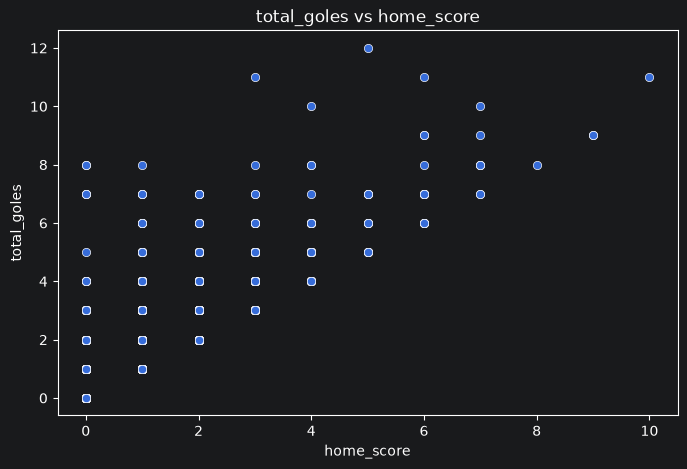

In [24]:
graficos.scatter(df_final, 'home_score', 'total_goles')

##### Claramente podemos afirmar que es cierta esa relacion, ya que entre más crecen los goles en casa, mas lo hace el total

#### Boxplot
##### Veremos la distribucion de los datos de la variable total de goles del dataset para vertificar de forma visual la deteccion de outliers que vimos en el EDA

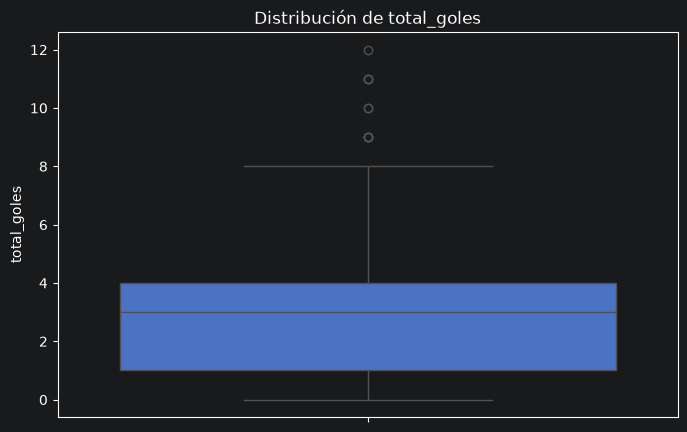

In [25]:
graficos.boxplot(df_final, 'total_goles')

##### Podemos confirmar como hemos visto en el EDA y graficos anteriores como el promedio total de goles a través de todos los anios es bajo, es grueso de los datos se encuentran muy concentrados de 1 a 4 goles con una media de 3, pero con la existencia de datos atipicos muy grandes arriba del límite superior, confirmamos también el sesgo a la derecha 